# Bai tap chuong 5: ma tran 

In [ ]:
import numpy as np

def print_augmented_matrix(A, b, step_name):
    """In ma trận bổ sung [A|b] định dạng 6 chữ số thập phân"""
    print(f"\n--- {step_name} ---")
    n = len(b)
    for i in range(n):
        row_str = "  ".join([f"{val:>12.6f}" for val in A[i]])
        print(f"| {row_str} | {b[i]:>12.6f} |")

def gauss_elimination(A, b):
    n = len(b)
    
    # 1. Giai đoạn Khử xuôi (Forward Elimination)
    print("\n[BẮT ĐẦU KHỬ XUÔI]")
    for k in range(n - 1):
        print(f"\n* Loại bỏ x_{k+1} ở các hàng dưới hàng {k+1}:")
        for i in range(k + 1, n):
            if A[k][k] == 0:
                print("Lỗi: Phần tử trụ bằng 0, cần đổi hàng!")
                return None
            
            factor = A[i][k] / A[k][k]
            print(f"  Hàng {i+1} = Hàng {i+1} - ({factor:.6f}) * Hàng {k+1}")
            
            # Cập nhật các phần tử của hàng i
            for j in range(k, n):
                A[i][j] -= factor * A[k][j]
            b[i] -= factor * b[k]
            
        print_augmented_matrix(A, b, f"Ma trận sau bước {k+1}")

    # 2. Giai đoạn Thế ngược (Back Substitution)
    print("\n[BẮT ĐẦU THẾ NGƯỢC]")
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        sum_ax = 0
        for j in range(i + 1, n):
            sum_ax += A[i][j] * x[j]
        
        x[i] = (b[i] - sum_ax) / A[i][i]
        print(f"  x_{i+1} = ({b[i]:.6f} - ({sum_ax:.6f})) / {A[i][i]:.6f} = {x[i]:.6f}")
    
    return x

# --- THIẾT LẬP DỮ LIỆU TỪ ẢNH ---
A = np.array([
    [3.0, -0.1, -0.2],
    [0.1, 7.0, -0.3],
    [0.3, -0.2, 10.0]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

# --- THỰC THI ---
print("HỆ PHƯƠNG TRÌNH BAN ĐẦU:")
print_augmented_matrix(A, b, "Ma trận [A|b]")

# Tạo bản sao để không làm hỏng dữ liệu gốc khi tính toán
A_copy = A.copy()
b_copy = b.copy()




HỆ PHƯƠNG TRÌNH BAN ĐẦU:

--- Ma trận [A|b] ---
|     3.000000     -0.100000     -0.200000 |     7.850000 |
|     0.100000      7.000000     -0.300000 |   -19.300000 |
|     0.300000     -0.200000     10.000000 |    71.400000 |

[BẮT ĐẦU KHỬ XUÔI]

* Loại bỏ x_1 ở các hàng dưới hàng 1:
  Hàng 2 = Hàng 2 - (0.033333) * Hàng 1
  Hàng 3 = Hàng 3 - (0.100000) * Hàng 1

--- Ma trận sau bước 1 ---
|     3.000000     -0.100000     -0.200000 |     7.850000 |
|     0.000000      7.003333     -0.293333 |   -19.561667 |
|     0.000000     -0.190000     10.020000 |    70.615000 |

* Loại bỏ x_2 ở các hàng dưới hàng 2:
  Hàng 3 = Hàng 3 - (-0.027130) * Hàng 2

--- Ma trận sau bước 2 ---
|     3.000000     -0.100000     -0.200000 |     7.850000 |
|     0.000000      7.003333     -0.293333 |   -19.561667 |
|     0.000000      0.000000     10.012042 |    70.084293 |

[BẮT ĐẦU THẾ NGƯỢC]
  x_3 = (70.084293 - (0.000000)) / 10.012042 = 7.000000
  x_2 = (-19.561667 - (-2.053333)) / 7.003333 = -2.500000
  

In [3]:
results = gauss_elimination(A_copy, b_copy)


[BẮT ĐẦU KHỬ XUÔI]

* Loại bỏ x_1 ở các hàng dưới hàng 1:
  Hàng 2 = Hàng 2 - (0.000000) * Hàng 1
  Hàng 3 = Hàng 3 - (0.000000) * Hàng 1

--- Ma trận sau bước 1 ---
|     3.000000     -0.100000     -0.200000 |     7.850000 |
|     0.000000      7.003333     -0.293333 |   -19.561667 |
|     0.000000      0.000000     10.012042 |    70.084293 |

* Loại bỏ x_2 ở các hàng dưới hàng 2:
  Hàng 3 = Hàng 3 - (0.000000) * Hàng 2

--- Ma trận sau bước 2 ---
|     3.000000     -0.100000     -0.200000 |     7.850000 |
|     0.000000      7.003333     -0.293333 |   -19.561667 |
|     0.000000      0.000000     10.012042 |    70.084293 |

[BẮT ĐẦU THẾ NGƯỢC]
  x_3 = (70.084293 - (0.000000)) / 10.012042 = 7.000000
  x_2 = (-19.561667 - (-2.053333)) / 7.003333 = -2.500000
  x_1 = (7.850000 - (-1.150000)) / 3.000000 = 3.000000


In [2]:

if results is not None:
    print("\n" + "="*40)
    print(f"{'BIẾN':<10} | {'GIÁ TRỊ NGHIỆM':<20}")
    print("-" * 40)
    for i, val in enumerate(results):
        print(f"x_{i+1:<8} | {val:<20.6f}")
    print("="*40)



BIẾN       | GIÁ TRỊ NGHIỆM      
----------------------------------------
x_1        | 3.000000            
x_2        | -2.500000           
x_3        | 7.000000            


Bài 9.7Cho hệ phương trình sau:$$0.5x_1 - x_2 = -9.5$$$$1.02x_1 - 2x_2 = -18.8$$(a) Giải bằng phương pháp đồ thị.(b) Tính định thức (determinant) của hệ.(c) Dựa trên kết quả của câu (a) và (b), bạn có dự đoán gì về tình trạng điều kiện (condition) của hệ phương trình này?Gợi ý: Hệ này là "điều kiện tốt" (well-conditioned) hay "điều kiện xấu" (ill-conditioned)?(d) Giải hệ phương trình bằng phương pháp khử ẩn số (elimination of unknowns).(e) Giải lại hệ phương trình một lần nữa, nhưng với hệ số $a_{11}$ được thay đổi nhẹ thành $0.52$. Hãy giải thích (biện luận) kết quả mà bạn tìm được.


1. Bảng tọa độ các điểm (phục vụ câu a)
---------------------------------------------
x1         | x2 (PT1)        | x2 (PT2)       
---------------------------------------------
0.00       | 9.500000        | 9.400000       
5.00       | 12.000000       | 11.950000      
10.00      | 14.500000       | 14.500000      
15.00      | 17.000000       | 17.050000      
20.00      | 19.500000       | 19.600000      
---------------------------------------------


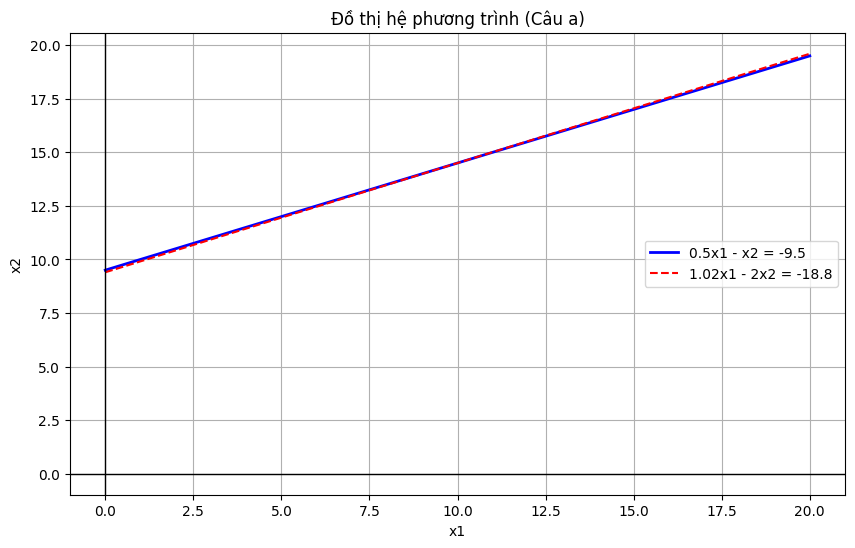


2. Định thức của hệ (Câu b):
   D = (0.5)*(-2.0) - (-1.0)*(1.02) = 0.0200

4. Dự đoán tình trạng điều kiện (Câu c):
   - Định thức D = 0.02 là một giá trị rất nhỏ so với các hệ số.
   - Hai đường thẳng có hệ số góc cực kỳ gần nhau (0.5 và 0.51).
   => Hệ này là ILL-CONDITIONED (Điều kiện xấu).

3. Giải hệ phương trình (Câu d) bằng phương pháp khử:
   Nghiệm tìm được: x1 = 10.000000, x2 = 14.500000

3. Giải hệ phương trình (Câu e - Khi a11 thay đổi 4%) bằng phương pháp khử:
   Nghiệm tìm được: x1 = -10.000000, x2 = 4.300000


(np.float64(-9.999999999999956), np.float64(4.300000000000023))

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def create_data_table(x_vals, y1, y2):
    """Vẽ bảng tọa độ các điểm trên hai đường thẳng để vẽ đồ thị"""
    print("\n1. Bảng tọa độ các điểm (phục vụ câu a)")
    print("-" * 45)
    print(f"{'x1':<10} | {'x2 (PT1)':<15} | {'x2 (PT2)':<15}")
    print("-" * 45)
    for i in range(len(x_vals)):
        print(f"{x_vals[i]:<10.2f} | {y1[i]:<15.6f} | {y2[i]:<15.6f}")
    print("-" * 45)

def solve_graphical(x_range):
    """Câu a: Giải bằng đồ thị"""
    # PT1: 0.5x1 - x2 = -9.5  => x2 = 0.5x1 + 9.5
    # PT2: 1.02x1 - 2x2 = -18.8 => x2 = 0.51x1 + 9.4
    x1 = np.linspace(x_range[0], x_range[1], 5)
    x2_line1 = 0.5 * x1 + 9.5
    x2_line2 = 0.51 * x1 + 9.4
    
    create_data_table(x1, x2_line1, x2_line2)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x1, x2_line1, label='0.5x1 - x2 = -9.5', color='blue', linewidth=2)
    plt.plot(x1, x2_line2, label='1.02x1 - 2x2 = -18.8', color='red', linestyle='--')
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.title("Đồ thị hệ phương trình (Câu a)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()

def calculate_determinant(A):
    """Câu b: Tính định thức"""
    det = A[0,0]*A[1,1] - A[0,1]*A[1,0]
    print(f"\n2. Định thức của hệ (Câu b):")
    print(f"   D = ({A[0,0]})*({A[1,1]}) - ({A[0,1]})*({A[1,0]}) = {det:.4f}")
    return det

def solve_elimination(A, b, label="Câu d"):
    """Câu d & e: Giải bằng phương pháp khử"""
    print(f"\n3. Giải hệ phương trình ({label}) bằng phương pháp khử:")
    # Nhân PT1 với 2: x1 - 2x2 = -19
    # Trừ PT2: (1 - 1.02)x1 = -19 - (-18.8)
    a11, a12, a21, a22 = A[0,0], A[0,1], A[1,0], A[1,1]
    b1, b2 = b[0], b[1]
    
    # Khử x2 bằng cách đưa hệ số x2 về giống nhau (-2)
    factor = 2.0
    new_a11 = a11 * factor
    new_b1 = b1 * factor
    
    x1 = (new_b1 - b2) / (new_a11 - a21)
    x2 = (a11 * x1 - b1) / (-a12) # Chuyển vế từ PT1
    
    print(f"   Nghiệm tìm được: x1 = {x1:.6f}, x2 = {x2:.6f}")
    return x1, x2

# --- THỰC THI BÀI TOÁN ---

# Thiết lập hệ số gốc
A_orig = np.array([[0.5, -1.0], [1.02, -2.0]])
b_orig = np.array([-9.5, -18.8])

# Câu a & b
solve_graphical([0, 20])
det = calculate_determinant(A_orig)

# Câu c: Biện luận
print("\n4. Dự đoán tình trạng điều kiện (Câu c):")
print("   - Định thức D = 0.02 là một giá trị rất nhỏ so với các hệ số.")
print("   - Hai đường thẳng có hệ số góc cực kỳ gần nhau (0.5 và 0.51).")
print("   => Hệ này là ILL-CONDITIONED (Điều kiện xấu).")

# Câu d
solve_elimination(A_orig, b_orig, "Câu d")

# Câu e: Thay đổi a11 thành 0.52
A_mod = np.array([[0.52, -1.0], [1.02, -2.0]])
b_mod = np.array([-9.5, -18.8])
solve_elimination(A_mod, b_mod, "Câu e - Khi a11 thay đổi 4%")

Bài 9.8Cho hệ phương trình sau:$$10x_1 + 2x_2 - x_3 = 27$$$$-3x_1 - 6x_2 + 2x_3 = -61.5$$$$x_1 + x_2 + 5x_3 = -21.5$$(a) Giải hệ phương trình bằng phương pháp khử Gauss sơ cấp (Naive Gauss elimination). Trình bày chi tiết tất cả các bước tính toán.Chú ý: Phương pháp "ngây thơ" (naive) có nghĩa là bạn thực hiện các bước khử mà không sử dụng kỹ thuật chọn phần tử trội (pivoting) để hoán đổi hàng.(b) Thế các kết quả tìm được vào hệ phương trình ban đầu để kiểm tra lại đáp án.

In [5]:
import numpy as np

def print_step(A, b, step_name):
    """In ma trận bổ sung [A|b] tại mỗi bước biến đổi"""
    print(f"\n--- {step_name} ---")
    n = len(b)
    for i in range(n):
        row_str = "  ".join([f"{val:>10.4f}" for val in A[i]])
        print(f"| {row_str} | {b[i]:>10.4f} |")

def naive_gauss_elimination(A, b):
    n = len(b)
    print("\n[BƯỚC 1: KHỬ XUÔI (FORWARD ELIMINATION)]")
    
    # Lặp qua từng cột trụ k
    for k in range(n - 1):
        pivot = A[k][k]
        print(f"\nDùng phần tử trụ a_{k+1}{k+1} = {pivot:.4f} để khử cột {k+1}:")
        
        for i in range(k + 1, n):
            # Tính nhân tử m (multiplier)
            factor = A[i][k] / pivot
            print(f"  Hàng {i+1} = Hàng {i+1} - ({factor:.4f}) * Hàng {k+1}")
            
            # Cập nhật các phần tử hàng i
            for j in range(k, n):
                A[i][j] = A[i][j] - factor * A[k][j]
            b[i] = b[i] - factor * b[k]
            
        print_step(A, b, f"Ma trận sau khi khử xong cột {k+1}")
        
    return A, b

def back_substitution(A, b):
    print("\n[BƯỚC 2: THẾ NGƯỢC (BACK SUBSTITUTION)]")
    n = len(b)
    x = np.zeros(n)
    
    for i in range(n - 1, -1, -1):
        sum_ax = 0
        for j in range(i + 1, n):
            sum_ax += A[i][j] * x[j]
        
        x[i] = (b[i] - sum_ax) / A[i][i]
        print(f"  x_{i+1} = ({b[i]:.4f} - ({sum_ax:.4f})) / {A[i][i]:.4f} = {x[i]:.4f}")
    
    return x

def verify_results(A_orig, b_orig, x):
    print("\n[BƯỚC 3: KIỂM TRA LẠI ĐÁP ÁN (VERIFICATION)]")
    print("-" * 50)
    print(f"{'Phương trình':<25} | {'Vế trái (LHS)':<10} | {'Vế phải (RHS)':<10}")
    print("-" * 50)
    
    for i in range(len(b_orig)):
        lhs = np.dot(A_orig[i], x)
        print(f"PT {i+1}: Sum(a_{i+1}j * xj) | {lhs:>10.4f} | {b_orig[i]:>10.4f}")
    print("-" * 50)

# --- THIẾT LẬP DỮ LIỆU BÀI 9.8 ---
A = np.array([
    [10.0, 2.0, -1.0],
    [-3.0, -6.0, 2.0],
    [1.0, 1.0, 5.0]
], dtype=float)

b = np.array([27.0, -61.5, -21.5], dtype=float)

# Lưu lại bản gốc để kiểm tra ở bước (b)
A_orig = A.copy()
b_orig = b.copy()

# Thực thi
print_step(A, b, "Ma trận bổ sung ban đầu")
A_final, b_final = naive_gauss_elimination(A, b)
x_sol = back_substitution(A_final, b_final)
verify_results(A_orig, b_orig, x_sol)


--- Ma trận bổ sung ban đầu ---
|    10.0000      2.0000     -1.0000 |    27.0000 |
|    -3.0000     -6.0000      2.0000 |   -61.5000 |
|     1.0000      1.0000      5.0000 |   -21.5000 |

[BƯỚC 1: KHỬ XUÔI (FORWARD ELIMINATION)]

Dùng phần tử trụ a_11 = 10.0000 để khử cột 1:
  Hàng 2 = Hàng 2 - (-0.3000) * Hàng 1
  Hàng 3 = Hàng 3 - (0.1000) * Hàng 1

--- Ma trận sau khi khử xong cột 1 ---
|    10.0000      2.0000     -1.0000 |    27.0000 |
|     0.0000     -5.4000      1.7000 |   -53.4000 |
|     0.0000      0.8000      5.1000 |   -24.2000 |

Dùng phần tử trụ a_22 = -5.4000 để khử cột 2:
  Hàng 3 = Hàng 3 - (-0.1481) * Hàng 2

--- Ma trận sau khi khử xong cột 2 ---
|    10.0000      2.0000     -1.0000 |    27.0000 |
|     0.0000     -5.4000      1.7000 |   -53.4000 |
|     0.0000      0.0000      5.3519 |   -32.1111 |

[BƯỚC 2: THẾ NGƯỢC (BACK SUBSTITUTION)]
  x_3 = (-32.1111 - (0.0000)) / 5.3519 = -6.0000
  x_2 = (-53.4000 - (-10.2000)) / -5.4000 = 8.0000
  x_1 = (27.0000 - (22.000

In [6]:
# tinh dinh thuc ma tran 3x3 
import numpy as np

def print_matrix_3x3(matrix):
    print("\n--- Ma trận A (3x3) ---")
    for row in matrix:
        print(f"| {row[0]:>8.2f} {row[1]:>8.2f} {row[2]:>8.2f} |")

def manual_determinant_3x3(A):
    """Tính định thức bằng công thức khai triển dòng 1"""
    d = (A[0][0] * (A[1][1] * A[2][2] - A[1][2] * A[2][1]) -
         A[0][1] * (A[1][0] * A[2][2] - A[1][2] * A[2][1]) +
         A[0][2] * (A[1][0] * A[2][1] - A[1][1] * A[2][0]))
    return d

def numpy_determinant(A):
    """Tính định thức bằng thư viện numpy chuyên dụng"""
    return np.linalg.det(A)

# --- CHƯƠNG TRÌNH CHÍNH ---

# Khai báo ma trận 3x3 mẫu
matrix_A = [
    [10, 2, -1],
    [-3, -6, 2],
    [1, 1, 5]
]

# Chuyển sang mảng numpy
A_np = np.array(matrix_A, dtype=float)

# Thực thi các phương thức
print_matrix_3x3(matrix_A)

det_manual = manual_determinant_3x3(matrix_A)
det_numpy = numpy_determinant(A_np)

print("\n--- KẾT QUẢ ---")
print(f"1. Tính thủ công:  det(A) = {det_manual:.4f}")
print(f"2. Dùng Numpy:     det(A) = {det_numpy:.4f}")

# Kiểm tra tính suy biến
if abs(det_numpy) < 1e-9:
    print("=> Kết luận: Ma trận suy biến (không có ma trận nghịch đảo).")
else:
    print("=> Kết luận: Ma trận không suy biến.")


--- Ma trận A (3x3) ---
|    10.00     2.00    -1.00 |
|    -3.00    -6.00     2.00 |
|     1.00     1.00     5.00 |

--- KẾT QUẢ ---
1. Tính thủ công:  det(A) = -289.0000
2. Dùng Numpy:     det(A) = -289.0000
=> Kết luận: Ma trận không suy biến.


# tinh ma tran A = LU

In [7]:
import numpy as np

def lu_decomposition(A):
    n = len(A)
    # Khởi tạo ma trận L là ma trận đơn vị và U là ma trận không
    L = np.eye(n)
    U = np.zeros((n, n))

    for i in range(n):
        # Tìm ma trận tam giác trên U
        for k in range(i, n):
            sum_val = sum(L[i][j] * U[j][k] for j in range(i))
            U[i][k] = A[i][k] - sum_val

        # Tìm ma trận tam giác dưới L
        for k in range(i + 1, n):
            sum_val = sum(L[k][j] * U[j][i] for j in range(i))
            if U[i][i] == 0:
                raise ValueError("Ma trận không thể phân rã LU (phần tử chốt bằng 0)")
            L[k][i] = (A[k][i] - sum_val) / U[i][i]

    return L, U

# 1. Khai báo ma trận A từ đề bài
A = np.array([
    [2, 3, 1],
    [4, 7, -3],
    [-2, 3, 2]
], dtype=float)

# 2. Thực hiện phân rã
try:
    L, U = lu_decomposition(A)

    print("--- Kết quả khai triển LU ---")
    print("\nMa trận L (Lower):")
    print(L)
    
    print("\nMa trận U (Upper):")
    print(U)

    # 3. Kiểm tra lại kết quả (L x U có bằng A không?)
    print("\n--- Kiểm tra kết quả (L * U) ---")
    A_check = np.dot(L, U)
    print(A_check)

except ValueError as e:
    print(f"Lỗi: {e}")

--- Kết quả khai triển LU ---

Ma trận L (Lower):
[[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-1.  6.  1.]]

Ma trận U (Upper):
[[ 2.  3.  1.]
 [ 0.  1. -5.]
 [ 0.  0. 33.]]

--- Kiểm tra kết quả (L * U) ---
[[ 2.  3.  1.]
 [ 4.  7. -3.]
 [-2.  3.  2.]]


In [8]:
# ma tran hiberet
import numpy as np

def create_hilbert_matrix(n):
    """Tạo ma trận Hilbert kích thước n x n"""
    H = np.zeros((n, n))
    for i in range(1, n + 1):
        for j in range(1, n + 1):
            H[i-1, j-1] = 1.0 / (i + j - 1)
    return H

def normalize_rows(A):
    """
    Chuẩn hóa ma trận bằng phương pháp Scaling: 
    Chia mỗi hàng cho phần tử có giá trị tuyệt đối lớn nhất của hàng đó.
    """
    A_norm = np.copy(A)
    for i in range(len(A)):
        row_max = np.max(np.abs(A[i]))
        if row_max != 0:
            A_norm[i] = A[i] / row_max
    return A_norm

# --- Thực thi bài toán ---
n = 5  # Bạn có thể thay đổi n để thấy số điều kiện tăng cực nhanh
H = create_hilbert_matrix(n)

# 1. Tính số điều kiện của ma trận gốc
cond_original = np.linalg.cond(H, p=np.inf)

# 2. Chuẩn hóa ma trận
H_normalized = normalize_rows(H)

# 3. Tính số điều kiện của ma trận đã chuẩn hóa
cond_normalized = np.linalg.cond(H_normalized, p=np.inf)

# --- Xuất kết quả ---
np.set_printoptions(precision=4, suppress=True) # Định dạng in số đẹp hơn
print(f"=== Ma trận Hilbert (n={n}) ===")
print(H)
print(f"Số điều kiện (Infinity Norm): {cond_original:.2e}")

print(f"\n=== Ma trận sau khi chuẩn hóa (Row Scaling) ===")
print(H_normalized)
print(f"Số điều kiện sau chuẩn hóa: {cond_normalized:.2e}")

# So sánh
print(f"\nNhận xét: Số điều kiện {'giảm' if cond_normalized < cond_original else 'không thay đổi nhiều'}.")

=== Ma trận Hilbert (n=5) ===
[[1.     0.5    0.3333 0.25   0.2   ]
 [0.5    0.3333 0.25   0.2    0.1667]
 [0.3333 0.25   0.2    0.1667 0.1429]
 [0.25   0.2    0.1667 0.1429 0.125 ]
 [0.2    0.1667 0.1429 0.125  0.1111]]
Số điều kiện (Infinity Norm): 9.44e+05

=== Ma trận sau khi chuẩn hóa (Row Scaling) ===
[[1.     0.5    0.3333 0.25   0.2   ]
 [1.     0.6667 0.5    0.4    0.3333]
 [1.     0.75   0.6    0.5    0.4286]
 [1.     0.8    0.6667 0.5714 0.5   ]
 [1.     0.8333 0.7143 0.625  0.5556]]
Số điều kiện sau chuẩn hóa: 4.34e+05

Nhận xét: Số điều kiện giảm.


Bài 10.2Hệ phương trình cho trước:$$7x_1 + 2x_2 - 3x_3 = -12$$$$2x_1 + 5x_2 - 3x_3 = -20$$$$x_1 - x_2 - 6x_3 = -26$$(a) Phân rã ma trậnYêu cầu: Sử dụng phương pháp khử Gauss sơ cấp (naive Gauss elimination) để phân rã hệ phương trình trên thành các ma trận $[L]$ và $[U]$.Kiểm tra: Sau khi phân rã, hãy thực hiện phép nhân hai ma trận vừa tìm được ($[L] \times [U]$) để xác nhận rằng kết quả trả về đúng ma trận hệ số $[A]$ ban đầu.(b) Giải hệ phương trìnhYêu cầu: Sử dụng kết quả phân rã $LU$ ở câu (a) để giải hệ phương trình.Lưu ý: Bạn phải trình bày chi tiết tất cả các bước tính toán (bao gồm bước thế tiến - forward substitution và thế ngược - back substitution).(c) Giải với vectơ vế phải thay thếYêu cầu: Tiếp tục sử dụng các ma trận $[L]$ và $[U]$ đã có để giải hệ phương trình nhưng với một vectơ vế phải (RHS) mới là: $\{B\}^T = [12 \quad 18 \quad -6]$.Ý nghĩa: Đây là ưu điểm lớn nhất của $LU$, khi vế phải thay đổi, bạn không cần phân rã lại ma trận $[A]$.

In [9]:
import numpy as np

def lu_decomposition(A):
    """
    Phân rã ma trận A thành L và U bằng phương pháp Doolittle (Naive Gauss).
    L có các phần tử đường chéo bằng 1.
    """
    n = len(A)
    L = np.eye(n)
    U = np.zeros((n, n))

    for i in range(n):
        # Tính hàng thứ i của U
        for k in range(i, n):
            sum_val = sum(L[i][j] * U[j][k] for j in range(i))
            U[i][k] = A[i][k] - sum_val

        # Tính cột thứ i của L
        for k in range(i + 1, n):
            sum_val = sum(L[k][j] * U[j][i] for j in range(i))
            if U[i][i] == 0:
                raise ValueError("Phần tử chốt bằng 0. Phân rã LU thất bại.")
            L[k][i] = (A[k][i] - sum_val) / U[i][i]
    return L, U

def forward_substitution(L, b):
    """Giải hệ Ly = b (Thế tiến)"""
    n = len(L)
    y = np.zeros(n)
    for i in range(n):
        sum_val = sum(L[i][j] * y[j] for j in range(i))
        y[i] = b[i] - sum_val
    return y

def backward_substitution(U, y):
    """Giải hệ Ux = y (Thế ngược)"""
    n = len(U)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        sum_val = sum(U[i][j] * x[j] for j in range(i + 1, n))
        x[i] = (y[i] - sum_val) / U[i][i]
    return x

# --- THỰC THI BÀI TOÁN ---

# Ma trận hệ số A
A = np.array([
    [7, 2, -3],
    [2, 5, -3],
    [1, -1, -6]
], dtype=float)

# Câu (a): Phân rã LU và Kiểm tra
print("--- CÂU (a): PHÂN RÃ LU ---")
L, U = lu_decomposition(A)
print("Ma trận L:\n", L)
print("Ma trận U:\n", U)

# Kiểm tra L * U = A
print("\nKiểm tra L * U (phải bằng A ban đầu):")
print(np.dot(L, U))

# Câu (b): Giải với vế phải b1 = [-12, -20, -26]
print("\n--- CÂU (b): GIẢI HỆ PHƯƠNG TRÌNH GỐC ---")
b1 = np.array([-12, -20, -26], dtype=float)

# Bước 1: Thế tiến Ly = b
y1 = forward_substitution(L, b1)
print(f"Kết quả thế tiến (y): {y1}")

# Bước 2: Thế ngược Ux = y
x1 = backward_substitution(U, y1)
print(f"Nghiệm cuối cùng (x): {x1}")

# Câu (c): Giải với vế phải mới b2 = [12, 18, -6]
print("\n--- CÂU (c): GIẢI VỚI VẾ PHẢI MỚI (RHS) ---")
b2 = np.array([12, 18, -6], dtype=float)

# Sử dụng lại L và U đã có, chỉ thực hiện thế tiến và thế ngược
y2 = forward_substitution(L, b2)
x2 = backward_substitution(U, y2)
print(f"Nghiệm với RHS mới: {x2}")

--- CÂU (a): PHÂN RÃ LU ---
Ma trận L:
 [[ 1.      0.      0.    ]
 [ 0.2857  1.      0.    ]
 [ 0.1429 -0.2903  1.    ]]
Ma trận U:
 [[ 7.      2.     -3.    ]
 [ 0.      4.4286 -2.1429]
 [ 0.      0.     -6.1935]]

Kiểm tra L * U (phải bằng A ban đầu):
[[ 7.  2. -3.]
 [ 2.  5. -3.]
 [ 1. -1. -6.]]

--- CÂU (b): GIẢI HỆ PHƯƠNG TRÌNH GỐC ---
Kết quả thế tiến (y): [-12.     -16.5714 -29.0968]
Nghiệm cuối cùng (x): [ 0.7188 -1.4688  4.6979]

--- CÂU (c): GIẢI VỚI VẾ PHẢI MỚI (RHS) ---
Nghiệm với RHS mới: [0.9375 3.5625 0.5625]


Bài 10.3Hệ phương trình cho trước:$$x_1 + 7x_2 - 4x_3 = -51$$$$4x_1 - 4x_2 + 9x_3 = 62$$$$12x_1 - x_2 + 3x_3 = 8$$(a) Giải bằng phân rã LUYêu cầu: Giải hệ phương trình bằng phương pháp phân rã $LU$ không sử dụng kỹ thuật chọn phần tử trội (without pivoting).(b) Tìm ma trận nghịch đảoYêu cầu: Tìm ma trận nghịch đảo $[A]^{-1}$ của hệ thống.Kiểm tra: Xác minh lại kết quả bằng cách thực hiện phép nhân $[A][A]^{-1}$ và kiểm tra xem nó có ra ma trận đơn vị $[I]$ hay không

In [10]:
import numpy as np

def lu_decomposition(A):
    """Phân rã LU không dùng pivoting (Naive)"""
    n = len(A)
    L = np.eye(n)
    U = A.copy()

    for i in range(n):
        for k in range(i + 1, n):
            # Tính hệ số nhân (multipliers)
            factor = U[k][i] / U[i][i]
            L[k][i] = factor
            # Khử các phần tử ở hàng dưới
            U[k][i:] = U[k][i:] - factor * U[i][i:]
            
    return L, U

def solve_lu(L, U, b):
    """Giải hệ Ax = b thông qua LU (Thế tiến và Thế ngược)"""
    n = len(L)
    # 1. Thế tiến: Ly = b
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])
    
    # 2. Thế ngược: Ux = y
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x

# --- THỰC THI BÀI TOÁN ---

# Ma trận A và vectơ b
A = np.array([
    [1, 7, -4],
    [4, -4, 9],
    [12, -1, 3]
], dtype=float)

b = np.array([-51, 62, 8], dtype=float)

# Câu (a): Giải hệ phương trình
print("--- CÂU (a): GIẢI HỆ PHƯƠNG TRÌNH ---")
L, U = lu_decomposition(A)
x_solution = solve_lu(L, U, b)
print(f"Nghiệm của hệ phương trình: {x_solution}")

# Câu (b): Tìm ma trận nghịch đảo A^-1
print("\n--- CÂU (b): TÌM MA TRẬN NGHỊCH ĐẢO ---")
n = len(A)
A_inv = np.zeros((n, n))
I = np.eye(n)

# Giải Ax = e_i cho từng cột của ma trận đơn vị
for i in range(n):
    # Cột thứ i của ma trận đơn vị là vế phải b_i
    e_i = I[:, i]
    column_inv = solve_lu(L, U, e_i)
    A_inv[:, i] = column_inv

print("Ma trận nghịch đảo [A]^-1:")
print(A_inv)

# Kiểm tra: A * A^-1
print("\n--- KIỂM TRA: [A] * [A]^-1 ---")
I_check = np.dot(A, A_inv)
print(np.round(I_check, 10)) # Làm tròn để dễ quan sát ma trận đơn vị

--- CÂU (a): GIẢI HỆ PHƯƠNG TRÌNH ---
Nghiệm của hệ phương trình: [-1.0649 -3.9229  5.6187]

--- CÂU (b): TÌM MA TRẬN NGHỊCH ĐẢO ---
Ma trận nghịch đảo [A]^-1:
[[-0.0061 -0.0345  0.0953]
 [ 0.1947  0.1034 -0.0507]
 [ 0.0892  0.1724 -0.0649]]

--- KIỂM TRA: [A] * [A]^-1 ---
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0. -0.  1.]]
